# Optimización Multi-Objetivo con NSGA-II y MLP: Maximizar Producción y Minimizar Consumo

Este cuaderno implementa la fase de optimización del proceso de pasteurización. Se utiliza el modelo predictivo (MLP) entrenado previamente como **función surrogate** para un **Algoritmo Genético Multi-Objetivo (NSGA-II)** implementado con `DEAP`.

**Resumen del Flujo de Trabajo:**
El algoritmo busca iterativamente el conjunto de soluciones óptimas (Frente de Pareto) que representen los mejores compromisos entre **maximizar la producción** (caudal de leche) y **minimizar el consumo energético**, garantizando siempre la seguridad alimentaria.

**Formulación Matemática del Problema (Bi-Objetivo con Restricción):**

* **Funciones Objetivo:**
$$\min f_1 = E_{consumo}(F_{flow}, T_{servicio} \mid T_{in}, t_{ciclo}, \Delta P) \quad [\text{kW}]$$
$$\max f_2 = F_{flow} \quad [\text{L/h}]$$

* **Restricción dura (vía penalización en fitness):**
$$T_{out\_leche}(F_{flow}, T_{servicio} \mid T_{in}, t_{ciclo}, \Delta P) \geq 72.3^\circ\text{C}$$

Las soluciones que no cumplan la restricción de pasteurización reciben una **penalización proporcional al déficit** de temperatura, lo que guía evolutivamente al GA hacia la zona factible.

* **Variables de Decisión (Cromosoma):**
    * $F_{flow}$: Caudal de alimentación $[3500 - 5500 \text{ L/h}]$.
    * $T_{servicio}$: Temperatura del agua de servicio $[76 - 95 ^\circ\text{C}]$.

* **Criterio de Selección:** Entre las soluciones factibles del Frente de Pareto, se selecciona aquella que minimiza el **consumo energético específico** $\frac{E_{consumo}}{F_{flow}}$ (kW por L/h), logrando el mejor balance producción-eficiencia.

* **Resultado:** Un **Frente de Pareto** que muestra el compromiso real entre producir más y consumir menos, sin sacrificar la seguridad alimentaria.

**Métricas Clave Reportadas:**
| Métrica | Símbolo | Unidades | Descripción |
|---------|---------|----------|-------------|
| Consumo energético | $E_{consumo}$ | kW | Potencia consumida por el intercambiador |
| Temperatura de salida | $T_{out\_leche}$ | °C | Temperatura de la leche pasteurizada |
| Caudal (producción) | $F_{flow}$ | L/h | Litros de leche procesados por hora |
| Consumo específico | $E/F$ | kW/(L/h) | Eficiencia: energía por unidad producida |

**Metodología:**
Basada en el enfoque híbrido ANN + GA Multi-Objetivo de *Yang et al. (2023)* — NSGA-II con Frente de Pareto — y *Abakarov et al. (2009)* para optimización térmica en procesamiento de alimentos. La formulación incluye explícitamente la maximización de la producción como objetivo, y la seguridad alimentaria como restricción penalizada en la función fitness.

In [12]:
# importaciones
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import json
import random
import os
import time as _time
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==========================================
# RECUPERAR ARTEFACTOS Y CONFIGURACIÓN
# ==========================================
ARTIFACTS_DIR = "../../models/artifacts"

# Cargar la configuración del modelo ganador
print(f"\U0001f4c2 Leyendo configuración desde {ARTIFACTS_DIR}/model_config.json...")
with open(f"{ARTIFACTS_DIR}/model_config.json", "r") as f:
    config = json.load(f)

# Extraer parámetros clave
INPUT_SIZE = config["input_size"]
OUTPUT_SIZE = config["output_size"]
NUM_LAYERS = config["num_layers"]
NEURONS = config["neurons"]
ACTIVATION = config["activation"]
FEATURES_ORDER = config["features_in_order"]
TARGETS_ORDER = config["targets_in_order"]

print(f"\u2705 Configuración cargada: MLP {INPUT_SIZE} -> {NUM_LAYERS} capas de {NEURONS} neuronas -> {OUTPUT_SIZE}")
print(f"\U0001f4cb Orden obligatorio de features: {FEATURES_ORDER}")

# Reconstruir la Clase del Modelo
class DynamicMLP(nn.Module):
    """Red Neuronal Multicapa que se construye al vuelo según los hiperparámetros."""
    def __init__(self, input_size, output_size, num_layers, neurons, activation):
        super(DynamicMLP, self).__init__()
        layers = []
        in_features = input_size
        act_fn = nn.ReLU() if activation == 'ReLU' else nn.Tanh()

        for _ in range(num_layers):
            layers.append(nn.Linear(in_features, neurons))
            layers.append(act_fn)
            in_features = neurons
            
        layers.append(nn.Linear(in_features, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Instanciar modelo y cargar pesos
model = DynamicMLP(INPUT_SIZE, OUTPUT_SIZE, NUM_LAYERS, NEURONS, ACTIVATION)
try:
    model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_predictor.pt"))
    model.eval()
    print("\u2705 Pesos del modelo cargados correctamente.")
except Exception as e:
    print(f"\u274c Error cargando pesos: {e}")

# Cargar Escaladores
scaler_X = joblib.load(f"{ARTIFACTS_DIR}/scaler_X.pkl")
scaler_y = joblib.load(f"{ARTIFACTS_DIR}/scaler_y.pkl")
print("\u2705 Escaladores (X e y) cargados.")

📂 Leyendo configuración desde ../../models/artifacts/model_config.json...
✅ Configuración cargada: MLP 5 -> 2 capas de 128 neuronas -> 2
📋 Orden obligatorio de features: ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
✅ Pesos del modelo cargados correctamente.
✅ Escaladores (X e y) cargados.


## Definición del Problema de Optimización Bi-Objetivo con Restricción

En estas celdas configuramos el algoritmo genético, concretamente la "caja de herramientas" (`Toolbox`) de DEAP, estableciendo la estructura biológica y las reglas matemáticas de evolución.

**Función de predicción (modelo de DL):** Recibe las variables de decisión (`F_flow`, `T_servicio`) y las condiciones externas fijas (`T_in_leche`, `t_ciclo`, `Delta_P`) y consulta al modelo MLP para obtener `E_consumo` y `T_out_leche`.

**Función de Fitness Bi-Objetivo:**
- **Objetivo 1:** Minimizar `E_consumo` (kW) → eficiencia energética.
- **Objetivo 2:** Maximizar `F_flow` (L/h) → maximizar producción.
- DEAP usa `weights=(-1.0, 1.0)` para minimizar el primero y maximizar el segundo.
- **Restricción:** `T_out_leche ≥ 72.3 °C` → seguridad alimentaria. Se aplica como **penalización proporcional al déficit** de temperatura directamente en la función fitness, lo que guía al GA hacia la zona factible sin eliminar prematuramente diversidad genética.

**Criterio de selección final:** Minimizar el consumo específico $\frac{E_{consumo}}{F_{flow}}$ $[\text{kW/(L/h)}]$ entre las soluciones factibles, lo que representa la **eficiencia energética por unidad de producción**.

> **Observación:** Al incluir `F_flow` como objetivo a maximizar, el algoritmo se ve forzado a explorar todo el rango de caudales, encontrando configuraciones que balancean producción industrial con eficiencia energética.

In [ ]:
# ==========================================
# FUNCION DE PREDICCION Y FITNESS BI-OBJETIVO
# (min E_consumo, max F_flow, restriccion T_out >= 72.3 C)
# ==========================================

# --- Limites del espacio de busqueda ---
BOUNDS = {
    'F_flow':     (3500.0, 5500.0),   # L/h  -- Limites operativos de la bomba
    'T_servicio': (76.0,   95.0),     # C    -- Limites de la caldera
}

# --- Restriccion de seguridad alimentaria ---
# Margen de seguridad termodinámico + tolerancia de instrumentación:
# Limit legal: 72.0°C. Setpoint: 72.3°C (+0.3°C para absorber incertidumbre
# del sensor PT100 Clase A ±0.3°C segun IEC 60751 y tolerancia PMO-FDA ±0.5°F)
T_OUT_MIN = 72.3   # C -- Temperatura minima de pasteurización con margen de seguridad

# --- Factor de penalizacion para soluciones infactibles ---
PENALTY_FACTOR = 10.0  # Severidad de la penalizacion por deficit de T_out

def predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P):
    """
    Envoltorio del modelo MLP: dado un escenario operativo completo,
    devuelve (E_consumo, T_out_leche) en unidades reales.
    """
    x_raw = np.array([[T_in_leche, F_flow, T_servicio, t_ciclo, Delta_P]])
    x_scaled = scaler_X.transform(x_raw)
    x_tensor = torch.FloatTensor(x_scaled)
    
    with torch.no_grad():
        y_scaled = model(x_tensor).numpy()
    y_real = scaler_y.inverse_transform(y_scaled)[0]
    return y_real[0], y_real[1]  # E_consumo, T_out_leche


def fitness_production_efficiency(individual, T_in_leche, t_ciclo, Delta_P):
    """
    Funcion de fitness BI-OBJETIVO con restriccion de temperatura.
    
    Objetivos (convencion DEAP multi-objetivo):
        - f1 = E_consumo   (a minimizar, weight = -1.0)
        - f2 = F_flow      (a maximizar, weight = +1.0)
    
    Restriccion:
        - T_out_leche >= 72.3 C (seguridad alimentaria)
        - Se aplica penalizacion proporcional al deficit de temperatura.
          Esto guia evolutivamente al GA hacia la zona factible sin
          eliminar prematuramente diversidad genetica.
    """
    F_flow, T_servicio = individual
    E_consumo, T_out = predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P)
    
    # --- Manejo de restriccion via penalizacion ---
    if T_out < T_OUT_MIN:
        deficit = T_OUT_MIN - T_out
        penalty = 1.0 + PENALTY_FACTOR * deficit
        E_penalized = float(E_consumo) * penalty
        F_penalized = float(F_flow) / penalty
        return (E_penalized, F_penalized)
    
    return (float(E_consumo), float(F_flow))


print("Funciones de prediccion y fitness bi-objetivo (produccion + eficiencia) definidas.")
print(f"   Espacio de busqueda: F_flow in {BOUNDS['F_flow']}, T_servicio in {BOUNDS['T_servicio']}")
print(f"   Objetivo 1: min E_consumo (kW)")
print(f"   Objetivo 2: max F_flow (L/h) -- MAXIMIZAR PRODUCCION")
print(f"   Restriccion (penalizada): T_out_leche >= {T_OUT_MIN} C")
print(f"   Factor de penalizacion: {PENALTY_FACTOR}")

Funciones de prediccion y fitness bi-objetivo (produccion + eficiencia) definidas.
   Espacio de busqueda: F_flow in (3500.0, 5500.0), T_servicio in (76.0, 95.0)
   Objetivo 1: min E_consumo (kW)
   Objetivo 2: max F_flow (L/h) -- MAXIMIZAR PRODUCCION
   Restriccion (penalizada): T_out_leche >= 72.3 C
   Factor de penalizacion: 10.0


In [ ]:
# ==========================================
# CONFIGURACION DE NSGA-II (DEAP)
# ==========================================

for cls_name in ["FitnessMulti", "Individual"]:
    if cls_name in creator.__dict__:
        del creator.__dict__[cls_name]

# --- Tipos base: BI-OBJETIVO ---
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, 1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

# --- Generadores de genes (variables de decision) ---
toolbox.register("attr_F_flow", random.uniform, BOUNDS['F_flow'][0], BOUNDS['F_flow'][1])
toolbox.register("attr_T_servicio", random.uniform, BOUNDS['T_servicio'][0], BOUNDS['T_servicio'][1])

# --- Individuo = [F_flow, T_servicio] ---
toolbox.register(
    "individual", tools.initCycle, creator.Individual,
    (toolbox.attr_F_flow, toolbox.attr_T_servicio), n=1
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Operadores geneticos ---
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutPolynomialBounded,
                  low=[BOUNDS['F_flow'][0], BOUNDS['T_servicio'][0]],
                  up=[BOUNDS['F_flow'][1], BOUNDS['T_servicio'][1]],
                  eta=20.0, indpb=0.3)

# --- NSGA-II: seleccion por dominancia + crowding distance ---
toolbox.register("select", tools.selNSGA2)

# --- Decorador para forzar limites tras cruce/mutacion ---
LOW = [BOUNDS['F_flow'][0], BOUNDS['T_servicio'][0]]
UP  = [BOUNDS['F_flow'][1], BOUNDS['T_servicio'][1]]

def checkBounds(low, up):
    """Decorador que clampea los genes a los limites permitidos."""
    def decorator(func):
        def wrapper(*args, **kw):
            offspring = func(*args, **kw)
            for child in offspring:
                for i, (lo, hi) in enumerate(zip(low, up)):
                    child[i] = max(lo, min(hi, child[i]))
            return offspring
        return wrapper
    return decorator

toolbox.decorate("mate", checkBounds(LOW, UP))
toolbox.decorate("mutate", checkBounds(LOW, UP))

# --- Parametros del GA Multi-Objetivo ---
GA_CONFIG = {
    'pop_size': 120,     # mu: tamanio de poblacion
    'lambda_': 100,      # lambda: hijos por generacion
    'n_gen': 1000,         # generaciones
    'cxpb': 0.9,         # probabilidad de cruce
    'mutpb': 0.1,        # probabilidad de mutacion
}

print("NSGA-II configurado con DEAP (bi-objetivo: min E_consumo, max F_flow).")
print(f"   Poblacion (mu): {GA_CONFIG['pop_size']} | Hijos (lambda): {GA_CONFIG['lambda_']}")
print(f"   Generaciones: {GA_CONFIG['n_gen']}")
print(f"   P(cruce): {GA_CONFIG['cxpb']} | P(mutacion): {GA_CONFIG['mutpb']}")
print(f"   Seleccion: NSGA-II (Non-dominated Sorting + Crowding Distance)")

NSGA-II configurado con DEAP (bi-objetivo: min E_consumo, max F_flow).
   Poblacion (mu): 120 | Hijos (lambda): 100
   Generaciones: 1000
   P(cruce): 0.9 | P(mutacion): 0.1
   Seleccion: NSGA-II (Non-dominated Sorting + Crowding Distance)


## Ejecución de NSGA-II — Escenario Base

Fijamos condiciones externas representativas:
- `T_in_leche = 4.0 °C` (temperatura media de entrada de la leche)
- `t_ciclo = 300 min` (punto medio de producción antes de CIP)
- `Delta_P = 0.65 bar` (caída de presión media)

NSGA-II buscará el **Frente de Pareto** — el conjunto de soluciones `(F_flow*, T_servicio*)` que representen los mejores compromisos entre **minimizar `E_consumo`** y **maximizar `F_flow`**, manteniendo `T_out ≥ 72.3 °C`.

**Criterio de selección:** Se elige la solución que minimiza el **consumo específico** $\frac{E_{consumo}}{F_{flow}}$ (kW·h/L), representando la máxima eficiencia energética por unidad producida.

In [ ]:
# ==========================================
# EJECUCION DE NSGA-II -- ESCENARIO BASE
# ==========================================

SCENARIO = {
    'T_in_leche': 4.0,   # C -- lectura del sensor de temperatura de entrada
    't_ciclo': 300,       # min -- tiempo transcurrido desde ultimo CIP
    'Delta_P': 0.65,      # bar -- lectura del sensor de presion diferencial
}

toolbox.register("evaluate", fitness_production_efficiency,
                  T_in_leche=SCENARIO['T_in_leche'],
                  t_ciclo=SCENARIO['t_ciclo'],
                  Delta_P=SCENARIO['Delta_P'])

random.seed(1)
np.random.seed(1)

pop = toolbox.population(n=GA_CONFIG['pop_size'])

stats_E = tools.Statistics(key=lambda ind: ind.fitness.values[0])
stats_E.register("min", np.min)
stats_E.register("avg", np.mean)

stats_F = tools.Statistics(key=lambda ind: ind.fitness.values[1])
stats_F.register("max", np.max)
stats_F.register("avg", np.mean)

mstats = tools.MultiStatistics(E_consumo=stats_E, F_flow=stats_F)

hof = tools.ParetoFront()

print(f"Iniciando NSGA-II para escenario: T_in={SCENARIO['T_in_leche']}C, "
      f"t_ciclo={SCENARIO['t_ciclo']} min, Delta_P={SCENARIO['Delta_P']} bar")
print(f"Objetivos: min E_consumo | max F_flow | Restriccion: T_out >= {T_OUT_MIN} C")
print("-" * 70)

t_start = _time.time()

pop_final, logbook = algorithms.eaMuPlusLambda(
    pop, toolbox,
    mu=GA_CONFIG['pop_size'],
    lambda_=GA_CONFIG['lambda_'],
    cxpb=GA_CONFIG['cxpb'],
    mutpb=GA_CONFIG['mutpb'],
    ngen=GA_CONFIG['n_gen'],
    stats=mstats,
    halloffame=hof,
    verbose=True
)

t_elapsed = _time.time() - t_start

pareto_front = tools.sortNondominated(pop_final, len(pop_final), first_front_only=True)[0]

pareto_details = []
for ind in pareto_front:
    F_flow_val, T_servicio_val = ind
    E_real, T_out_real = predict_with_model(
        F_flow_val, T_servicio_val,
        SCENARIO['T_in_leche'], SCENARIO['t_ciclo'], SCENARIO['Delta_P']
    )
    pareto_details.append({
        'ind': ind,
        'F_flow': F_flow_val,
        'T_servicio': T_servicio_val,
        'E_consumo': float(E_real),
        'T_out': float(T_out_real),
        'factible': float(T_out_real) >= T_OUT_MIN,
        'consumo_especifico': float(E_real) / max(F_flow_val, 1.0)
    })

pareto_E = [d['E_consumo'] for d in pareto_details]
pareto_F = [d['F_flow'] for d in pareto_details]
pareto_T = [d['T_out'] for d in pareto_details]

feasible = [d for d in pareto_details if d['factible']]

if feasible:
    feasible.sort(key=lambda x: x['consumo_especifico'])
    best = feasible[0]
    best_ind = best['ind']
    best_F_flow = best['F_flow']
    best_T_servicio = best['T_servicio']
    best_E = best['E_consumo']
    best_T_out = best['T_out']
    best_consumo_esp = best['consumo_especifico']
else:
    pareto_details.sort(key=lambda x: x['consumo_especifico'])
    best = pareto_details[0]
    best_ind = best['ind']
    best_F_flow = best['F_flow']
    best_T_servicio = best['T_servicio']
    best_E = best['E_consumo']
    best_T_out = best['T_out']
    best_consumo_esp = best['consumo_especifico']

t_out_status = "OK" if best_T_out >= T_OUT_MIN else "VIOLA RESTRICCION"

print("=" * 70)
print("FRENTE DE PARETO (escenario base)")
print("=" * 70)
print(f"   Soluciones en el frente de Pareto:  {len(pareto_front)}")
print(f"   Soluciones factibles (T_out>=72.3C):  {len(feasible)}")
print(f"   Rango E_consumo: [{min(pareto_E):.2f}, {max(pareto_E):.2f}] kW")
print(f"   Rango F_flow:    [{min(pareto_F):.2f}, {max(pareto_F):.2f}] L/h")
print(f"   Rango T_out:     [{min(pareto_T):.2f}, {max(pareto_T):.2f}] C")
print("-" * 70)
print("SOLUCION SELECCIONADA (min consumo especifico E/F con T_out >= 72.3 C)")
print("-" * 70)
print(f"   F_flow*          = {best_F_flow:.2f} L/h")
print(f"   T_servicio*      = {best_T_servicio:.2f} C")
print(f"   E_consumo        = {best_E:.2f} kW")
print(f"   T_out_leche      = {best_T_out:.2f} C  [{t_out_status}]")
print(f"   Consumo espec.   = {best_consumo_esp:.4f} kW/(L/h)")
print(f"   Tiempo NSGA-II:  {t_elapsed:.2f} s")

Iniciando NSGA-II para escenario: T_in=4.0C, t_ciclo=300 min, Delta_P=0.65 bar
Objetivos: min E_consumo | max F_flow | Restriccion: T_out >= 72.3 C
----------------------------------------------------------------------
   	      	          E_consumo           	            F_flow            
   	      	------------------------------	------------------------------
gen	nevals	avg    	gen	min   	nevals	avg    	gen	max    	nevals
0  	120   	550.671	0  	365.06	120   	4226.75	0  	5485.09	120   
1  	100   	409.271	1  	365.06	100   	4483.33	1  	5500   	100   
2  	100   	402.888	2  	364.112	100   	4469.97	2  	5500   	100   
3  	100   	395.477	3  	364.112	100   	4394.71	3  	5500   	100   
4  	100   	389.616	4  	363.859	100   	4304.68	4  	5500   	100   
5  	100   	392.122	5  	363.765	100   	4373.77	5  	5500   	100   
6  	100   	394.128	6  	363.765	100   	4416.14	6  	5500   	100   
7  	100   	395.404	7  	363.765	100   	4444.07	7  	5500   	100   
8  	100   	394.852	8  	363.765	100   	4426.39	8  	550

## Frente de Pareto, Convergencia y Tabla de Soluciones

*En esta celda tomamos los resultados crudos del GA (el pop_final, el pareto_front y el logbook generados en la celda anterior) y los transformamos en gráficos y tablas legibles.*

Visualización del frente de Pareto en el espacio objetivo ($E_{consumo}$ vs $F_{flow}$), curvas de convergencia multi-objetivo, y tabla detallada de soluciones Pareto-óptimas incluyendo el **consumo específico** $E/F$ (análoga a la Table 5 de Yang et al., 2023).

- **Frente de Pareto**: En problemas con múltiples objetivos que compiten entre sí (ej. gastar poca energía vs. producir mucha leche), no existe una única solución perfecta. El Frente de Pareto agrupa todas las soluciones "no dominadas". Muestra el límite físico del sistema: "si quieres producir X L/h más, necesitas gastar Y kW adicionales". Cualquier punto por encima de esta curva es inalcanzable, y cualquier punto por debajo es ineficiente.
- **Curvas de convergencia multi-objetivo**: Gráficos de líneas que muestran cómo han evolucionado los objetivos (energía y caudal) a lo largo de las generaciones del algoritmo. Demuestran que el algoritmo ha mejorado gradualmente hasta "estancarse" (converger), lo que indica que ha encontrado el límite matemático óptimo.
- **Tabla detallada de soluciones Pareto-óptimas**: Traduce los puntos del gráfico a configuraciones exactas de la máquina. Es un "menú" que lista las mejores combinaciones de setpoints (Flujo y T_servicio), permitiendo aplicar filtros de negocio o restricciones legales (como verificar que se superan los 72.3 °C de seguridad alimentaria).

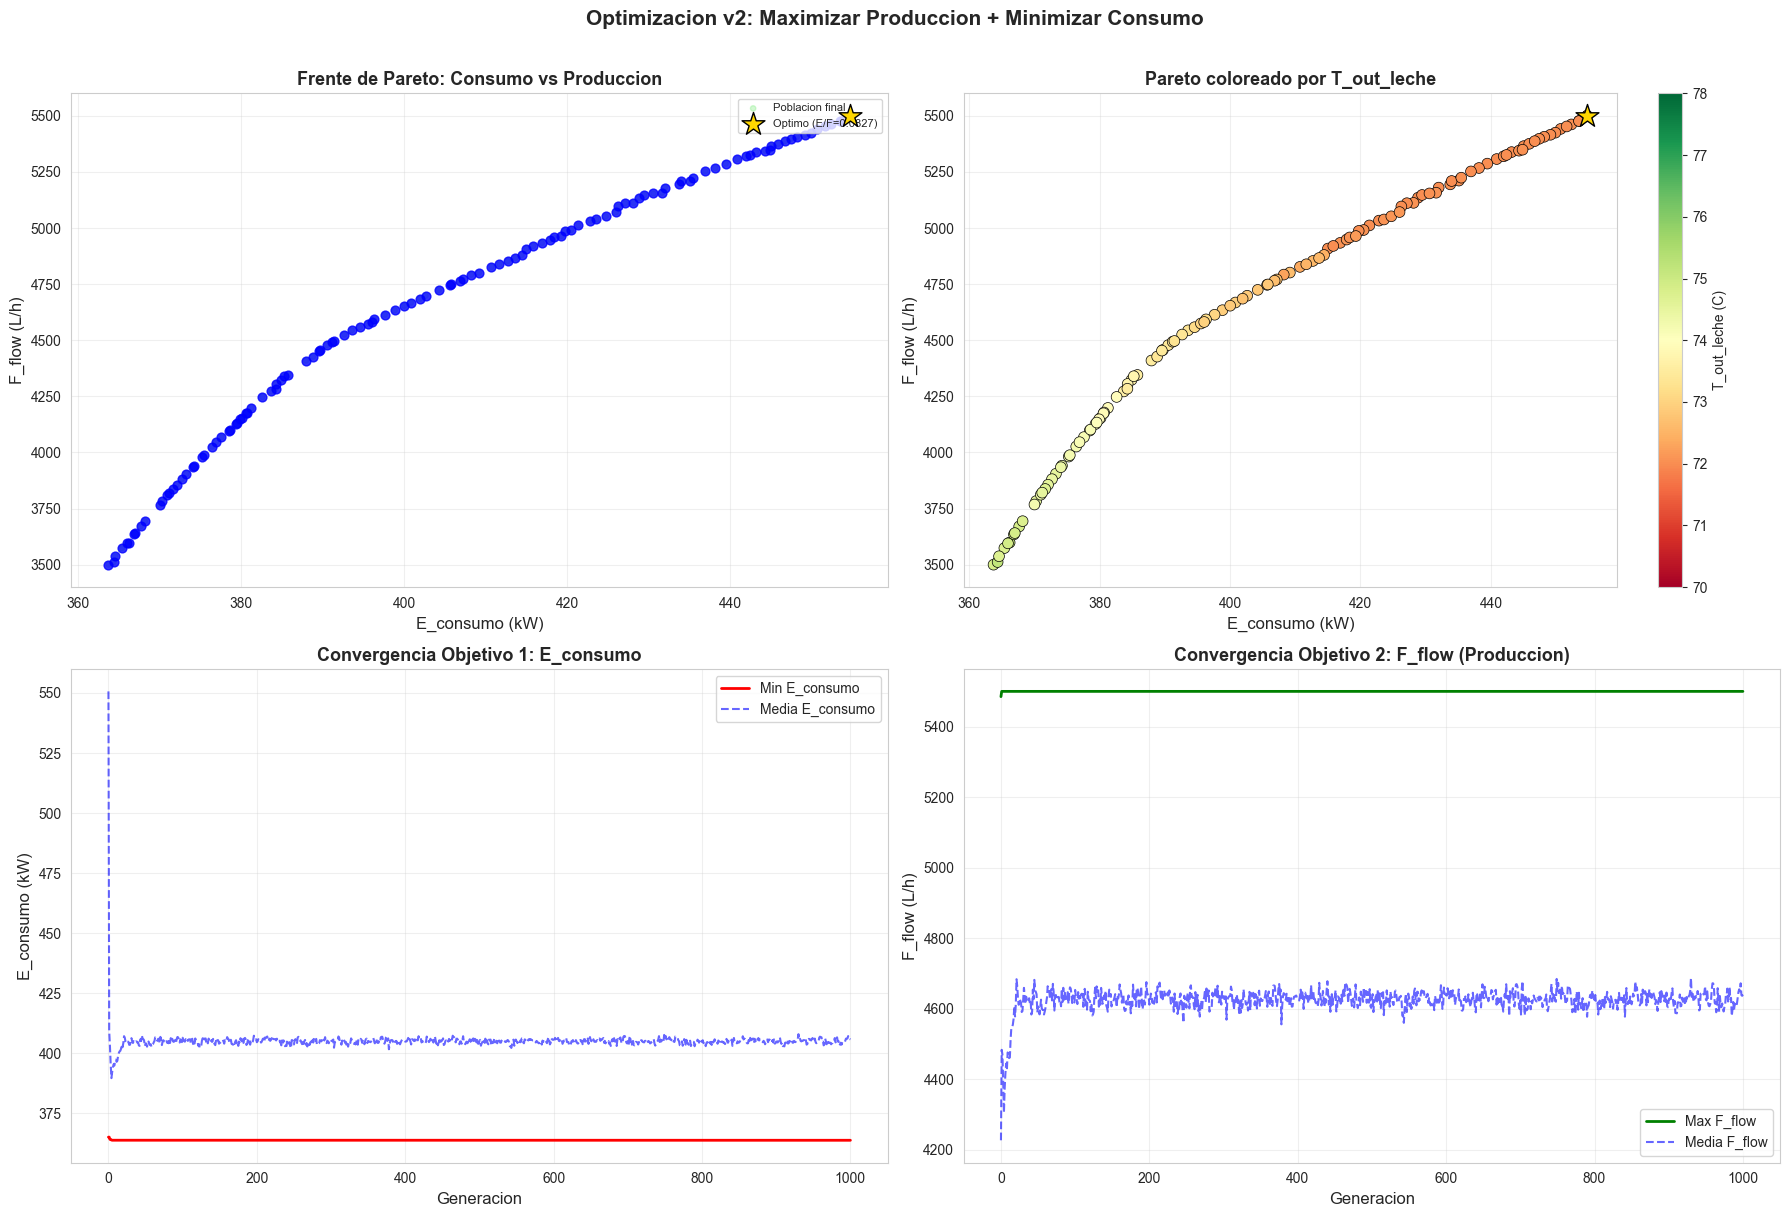

TABLA DE SOLUCIONES PARETO-OPTIMAS (ordenadas por consumo especifico E/F)
  #  F_flow (L/h)  T_servicio (C)  E_consumo (kW)  T_out (C)  E/F (kW per L/h) Factible
  1        5500.0            80.9          454.75      72.00           0.08268       SI
  2        5500.0            80.9          454.75      72.00           0.08268       SI
  3        5477.3            80.9          453.55      72.01           0.08280       SI
  4        5476.4            80.9          453.49      72.01           0.08281       SI
  5        5461.5            80.9          452.35      72.01           0.08282       SI
  6        5441.4            80.8          450.70      72.00           0.08283       SI
  7        5452.4            80.9          451.61      72.00           0.08283       SI
  8        5397.5            80.8          447.40      72.00           0.08289       SI
  9        5406.5            80.8          448.17      72.00           0.08289       SI
 10        5387.1            80.7          446

In [ ]:
# ==========================================
# FRENTE DE PARETO, CONVERGENCIA Y TABLA
# ==========================================
sns.set_style("whitegrid")
IMAGES_DIR = "../../data/images"
os.makedirs(IMAGES_DIR, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Frente de Pareto en espacio objetivo (E_consumo vs F_flow) ---
# Poblacion final completa (gris)
all_E = []
all_F = []
all_T_check = []
for ind in pop_final:
    E_r, T_r = predict_with_model(
        ind[0], ind[1],
        SCENARIO['T_in_leche'], SCENARIO['t_ciclo'], SCENARIO['Delta_P']
    )
    all_E.append(float(E_r))
    all_F.append(ind[0])
    all_T_check.append(float(T_r))

# Color segun factibilidad
colors_pop = ['lightgreen' if t >= T_OUT_MIN else 'lightcoral' for t in all_T_check]
axes[0, 0].scatter(all_E, all_F, c=colors_pop, s=15, alpha=0.4, label='Poblacion final')

# Frente de Pareto factible (azul) e infactible (rojo)
for d in pareto_details:
    color = 'blue' if d['factible'] else 'red'
    marker = 'o' if d['factible'] else 'x'
    axes[0, 0].scatter(d['E_consumo'], d['F_flow'], c=color, s=40, marker=marker, alpha=0.8, zorder=5)

# Solucion seleccionada
axes[0, 0].scatter(best_E, best_F_flow, c='gold', s=300, marker='*', zorder=10, 
                edgecolors='black', linewidths=1.0, label=f'Optimo (E/F={best_consumo_esp:.4f})')

axes[0, 0].set_xlabel("E_consumo (kW)", fontsize=12)
axes[0, 0].set_ylabel("F_flow (L/h)", fontsize=12)
axes[0, 0].set_title("Frente de Pareto: Consumo vs Produccion", fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=8, loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# --- Pareto coloreado por T_out (verificacion de restriccion) ---
sc = axes[0, 1].scatter(
    [d['E_consumo'] for d in pareto_details],
    [d['F_flow'] for d in pareto_details],
    c=[d['T_out'] for d in pareto_details],
    cmap='RdYlGn', s=60, edgecolors='black', linewidths=0.5, zorder=5,
    vmin=70, vmax=78
)
axes[0, 1].scatter(best_E, best_F_flow, c='gold', s=300, marker='*', zorder=10,
                edgecolors='black', linewidths=1.0)
cbar = plt.colorbar(sc, ax=axes[0, 1])
cbar.set_label('T_out_leche (C)', fontsize=10)
axes[0, 1].set_xlabel("E_consumo (kW)", fontsize=12)
axes[0, 1].set_ylabel("F_flow (L/h)", fontsize=12)
axes[0, 1].set_title("Pareto coloreado por T_out_leche", fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# --- Convergencia de E_consumo ---
gen = logbook.select("gen")
min_E = logbook.chapters["E_consumo"].select("min")
avg_E = logbook.chapters["E_consumo"].select("avg")

axes[1, 0].plot(gen, min_E, 'r-', linewidth=2, label='Min E_consumo')
axes[1, 0].plot(gen, avg_E, 'b--', alpha=0.6, label='Media E_consumo')
axes[1, 0].set_xlabel("Generacion", fontsize=12)
axes[1, 0].set_ylabel("E_consumo (kW)", fontsize=12)
axes[1, 0].set_title("Convergencia Objetivo 1: E_consumo", fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# --- Convergencia de F_flow ---
max_F = logbook.chapters["F_flow"].select("max")
avg_F = logbook.chapters["F_flow"].select("avg")

axes[1, 1].plot(gen, max_F, 'g-', linewidth=2, label='Max F_flow')
axes[1, 1].plot(gen, avg_F, 'b--', alpha=0.6, label='Media F_flow')
axes[1, 1].set_xlabel("Generacion", fontsize=12)
axes[1, 1].set_ylabel("F_flow (L/h)", fontsize=12)
axes[1, 1].set_title("Convergencia Objetivo 2: F_flow (Produccion)", fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Optimizacion v2: Maximizar Produccion + Minimizar Consumo", 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/ga_v2_pareto_convergence.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Tabla de soluciones Pareto ---
pareto_table = []
for i, d in enumerate(sorted(pareto_details, key=lambda x: x['consumo_especifico'])):
    pareto_table.append({
        '#': i + 1,
        'F_flow (L/h)': round(d['F_flow'], 1),
        'T_servicio (C)': round(d['T_servicio'], 1),
        'E_consumo (kW)': round(d['E_consumo'], 2),
        'T_out (C)': round(d['T_out'], 2),
        'E/F (kW per L/h)': round(d['consumo_especifico'], 5),
        'Factible': 'SI' if d['factible'] else 'NO'
    })

df_pareto = pd.DataFrame(pareto_table)
print("=" * 100)
print("TABLA DE SOLUCIONES PARETO-OPTIMAS (ordenadas por consumo especifico E/F)")
print("=" * 100)
print(df_pareto.to_string(index=False))
print(f"\nTotal: {len(df_pareto)} soluciones | "
      f"Factibles: {(df_pareto['Factible'] == 'SI').sum()} | "
      f"Infactibles: {(df_pareto['Factible'] == 'NO').sum()}")
print(f"Solucion seleccionada: #{pareto_table[0]['#']} (min consumo especifico factible)")

## Análisis Multi-Escenario con NSGA-II

Evaluamos la robustez del optimizador bajo diferentes condiciones operativas. Para cada escenario se reportan:
- **E_consumo** (kW): consumo energético óptimo
- **F_flow** (L/h): caudal (producción) óptimo
- **T_out_leche** (°C): temperatura de salida — ¿se cumple la restricción de pasteurización?
- **Consumo_Esp** (kW/(L/h)): consumo específico — eficiencia por unidad de producción

In [ ]:
# ==========================================
# ANALISIS MULTI-ESCENARIO CON NSGA-II
# ==========================================

# --- Cargar datos historicos para obtener Delta_P representativo ---
DATA_PATH = "../../data/processed/final_data_sim.csv"
df_hist = pd.read_csv(DATA_PATH)
if 'Is_Cleaning' in df_hist.columns:
    df_hist = df_hist[df_hist['Is_Cleaning'] == 0].copy()

# Escenarios a evaluar
T_in_values = [1.0, 2.0, 4.0, 6.0, 8.0]
t_ciclo_values = [50, 150, 300, 500, 750]

def get_delta_p_for_tciclo(t_cyc, df, window=50):
    mask = (df['t_ciclo'] >= t_cyc - window) & (df['t_ciclo'] <= t_cyc + window)
    sub = df.loc[mask, 'Delta_P']
    return sub.median() if len(sub) > 0 else df['Delta_P'].median()

results = []
total = len(T_in_values) * len(t_ciclo_values)
idx = 0

for T_in in T_in_values:
    for t_cyc in t_ciclo_values:
        idx += 1
        dp = get_delta_p_for_tciclo(t_cyc, df_hist)

        # Re-registrar fitness con nuevas condiciones
        toolbox.unregister("evaluate")
        toolbox.register("evaluate", fitness_production_efficiency,
                         T_in_leche=T_in, t_ciclo=t_cyc, Delta_P=dp)

        # Reproducibilidad por escenario
        random.seed(1)
        np.random.seed(1)

        pop_s = toolbox.population(n=GA_CONFIG['pop_size'])
        hof_s = tools.ParetoFront()

        pop_s, _ = algorithms.eaMuPlusLambda(
            pop_s, toolbox,
            mu=GA_CONFIG['pop_size'],
            lambda_=GA_CONFIG['lambda_'],
            cxpb=GA_CONFIG['cxpb'],
            mutpb=GA_CONFIG['mutpb'],
            ngen=GA_CONFIG['n_gen'],
            halloffame=hof_s,
            verbose=False
        )

        # Extraer Pareto front y re-evaluar sin penalizacion
        pf = tools.sortNondominated(pop_s, len(pop_s), first_front_only=True)[0]
        
        pf_details = []
        for ind in pf:
            E_r, T_r = predict_with_model(ind[0], ind[1], T_in, t_cyc, dp)
            pf_details.append({
                'ind': ind,
                'F_flow': ind[0],
                'T_servicio': ind[1],
                'E_consumo': float(E_r),
                'T_out': float(T_r),
                'factible': float(T_r) >= T_OUT_MIN,
                'consumo_especifico': float(E_r) / max(ind[0], 1.0)
            })
        
        feasible_s = [d for d in pf_details if d['factible']]
        
        if feasible_s:
            feasible_s.sort(key=lambda x: x['consumo_especifico'])
            best_d = feasible_s[0]
        else:
            pf_details.sort(key=lambda x: x['consumo_especifico'])
            best_d = pf_details[0]

        n_pareto = len(pf)
        n_feasible = len(feasible_s)

        results.append({
            'T_in_leche': T_in,
            't_ciclo': t_cyc,
            'Delta_P': round(dp, 4),
            'F_flow_opt': round(best_d['F_flow'], 2),
            'T_servicio_opt': round(best_d['T_servicio'], 2),
            'E_consumo_opt': round(best_d['E_consumo'], 2),
            'T_out_leche': round(best_d['T_out'], 2),
            'Consumo_Esp': round(best_d['consumo_especifico'], 5),
            'N_Pareto': n_pareto,
            'N_Factibles': n_feasible,
            'Seguro': 'SI' if best_d['T_out'] >= T_OUT_MIN else 'NO'
        })
        print(f"  [{idx}/{total}] T_in={T_in}, t_ciclo={t_cyc}, dP={dp:.3f} "
              f"-> E={best_d['E_consumo']:.2f} kW, F={best_d['F_flow']:.0f} L/h, "
              f"T_out={best_d['T_out']:.2f} C  "
              f"(Pareto: {n_pareto}, Factibles: {n_feasible})")

df_results = pd.DataFrame(results)
print("\n" + "=" * 100)
print("RESULTADOS MULTI-ESCENARIO (NSGA-II v2: max produccion + min consumo)")
print("=" * 100)
print(df_results.to_string(index=False))

# Guardar en CSV
PREDICTIONS_DIR = "../../data/predictions"
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
df_results.to_csv(f"{PREDICTIONS_DIR}/ga_v2_optimization_results.csv", index=False)
print(f"\nResultados guardados en {PREDICTIONS_DIR}/ga_v2_optimization_results.csv")

  [1/25] T_in=1.0, t_ciclo=50, dP=0.547 -> E=461.51 kW, F=5500 L/h, T_out=72.00 C  (Pareto: 120, Factibles: 120)
  [2/25] T_in=1.0, t_ciclo=150, dP=0.586 -> E=463.53 kW, F=5500 L/h, T_out=72.00 C  (Pareto: 120, Factibles: 120)
  [3/25] T_in=1.0, t_ciclo=300, dP=0.649 -> E=466.63 kW, F=5500 L/h, T_out=72.00 C  (Pareto: 120, Factibles: 120)
  [4/25] T_in=1.0, t_ciclo=500, dP=0.735 -> E=470.95 kW, F=5500 L/h, T_out=72.00 C  (Pareto: 120, Factibles: 120)
  [5/25] T_in=1.0, t_ciclo=750, dP=0.837 -> E=474.63 kW, F=5500 L/h, T_out=72.00 C  (Pareto: 120, Factibles: 119)
  [6/25] T_in=2.0, t_ciclo=50, dP=0.547 -> E=458.21 kW, F=5500 L/h, T_out=72.00 C  (Pareto: 120, Factibles: 120)
  [7/25] T_in=2.0, t_ciclo=150, dP=0.586 -> E=460.28 kW, F=5500 L/h, T_out=72.00 C  (Pareto: 120, Factibles: 120)
  [8/25] T_in=2.0, t_ciclo=300, dP=0.649 -> E=463.20 kW, F=5500 L/h, T_out=72.00 C  (Pareto: 120, Factibles: 120)
  [9/25] T_in=2.0, t_ciclo=500, dP=0.735 -> E=467.01 kW, F=5500 L/h, T_out=72.00 C  (Paret

## Visualización Multi-Escenario

Mapas de calor que muestran cómo varían las decisiones óptimas y las métricas clave en función de las condiciones externas:
- **E_consumo** (kW): ¿cuánta energía se consume?
- **F_flow** (L/h): ¿cuánta leche se produce?
- **T_out_leche** (°C): ¿se garantiza la pasteurización?
- **T_servicio** (°C): ¿a qué temperatura se fija la caldera?
- **Consumo específico E/F** (kW/(L/h)): ¿cuán eficiente es la producción?
- **Margen de seguridad** (°C): ¿cuánto margen hay sobre los 72.3 °C?

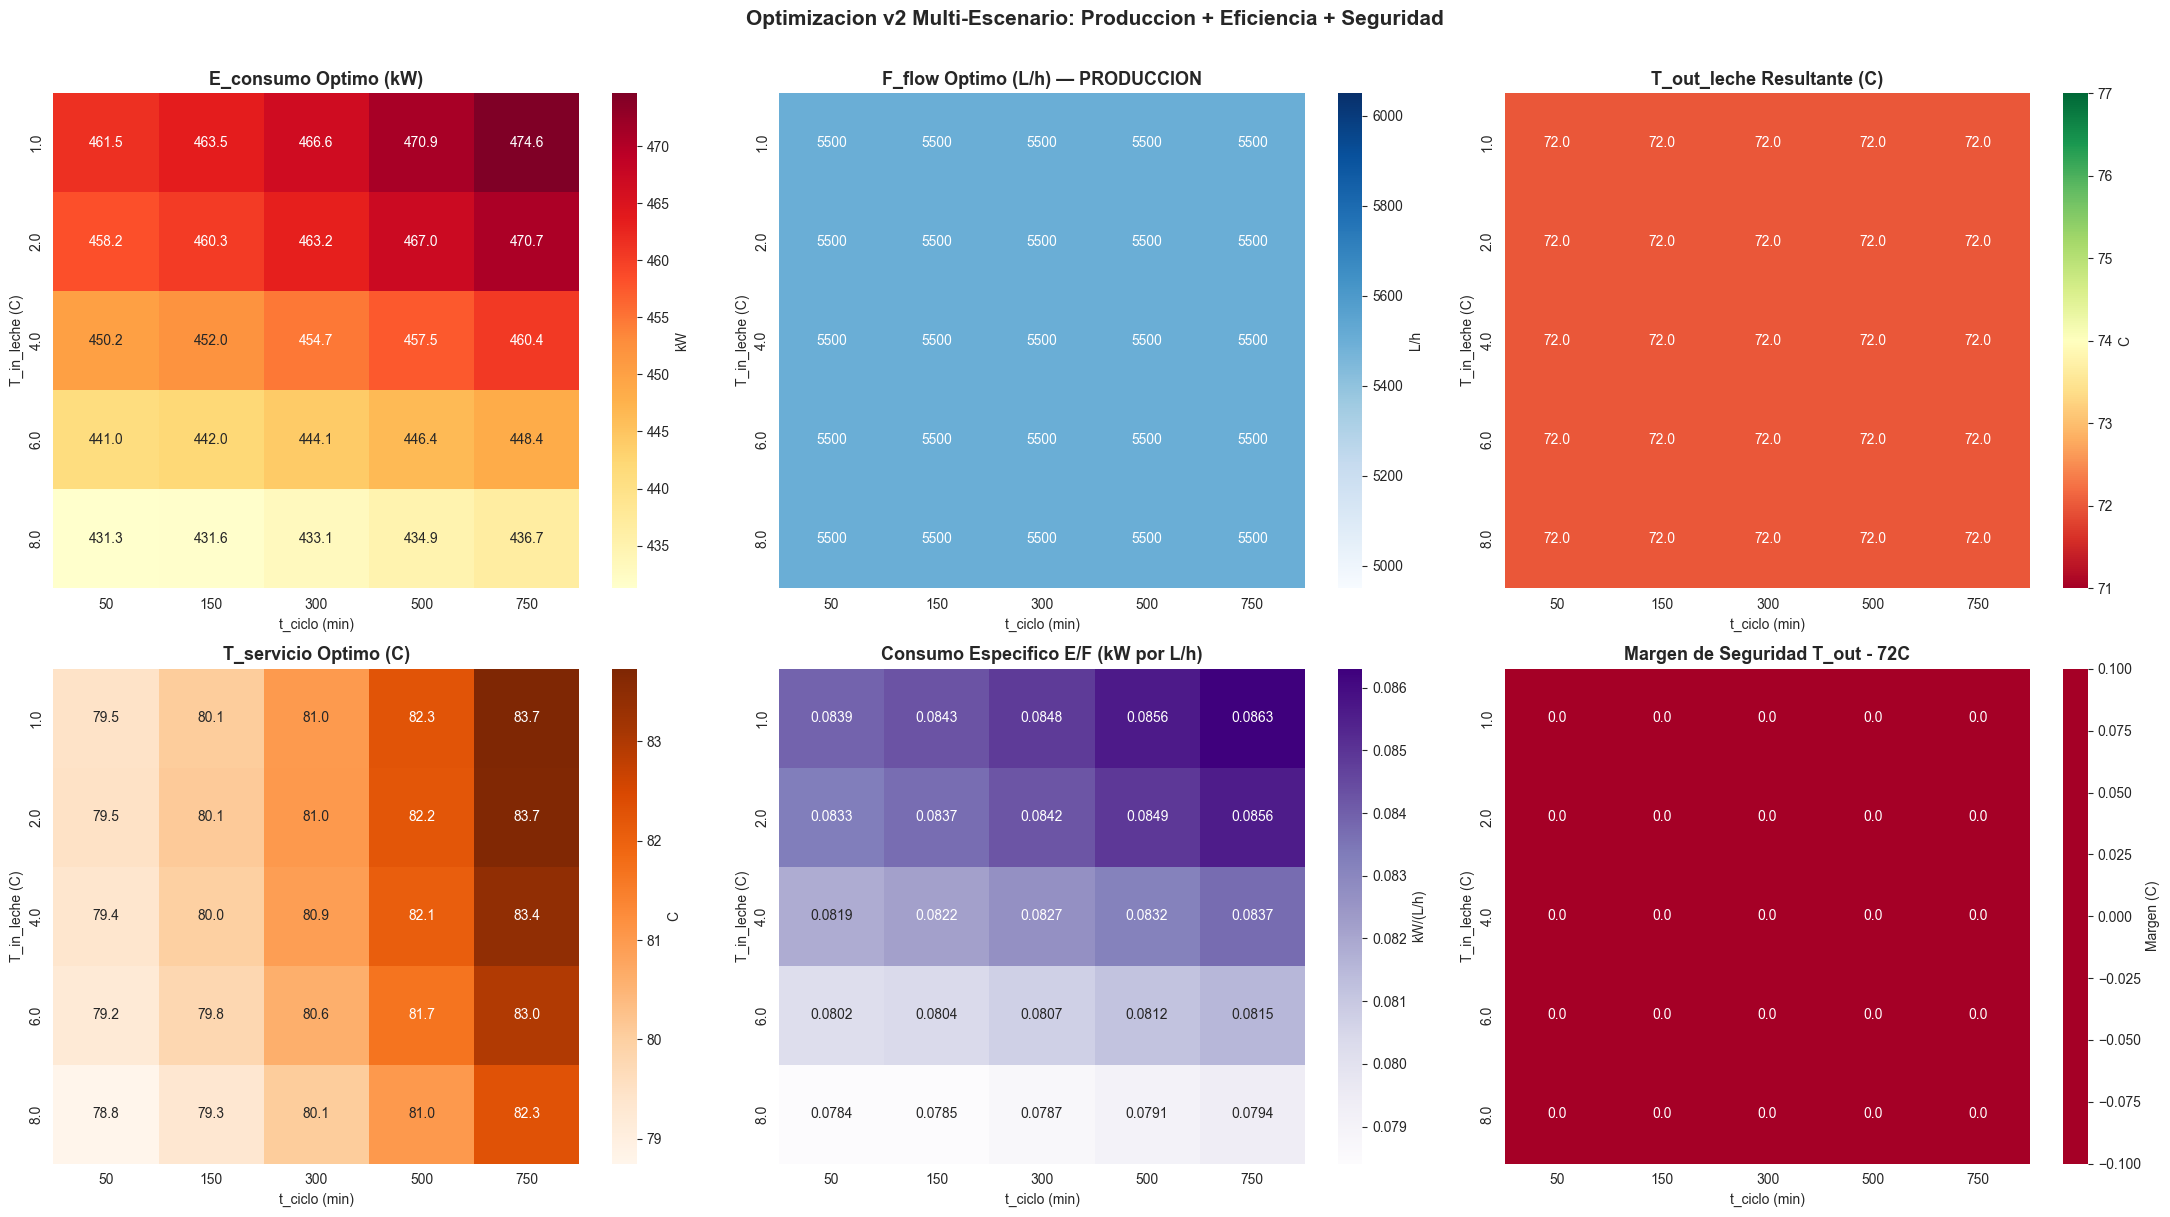

✅ Mapas de calor guardados.


In [ ]:
# ==========================================
# VISUALIZACION MULTI-ESCENARIO
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# Preparar pivots
pivot_E = df_results.pivot(index='T_in_leche', columns='t_ciclo', values='E_consumo_opt')
pivot_T = df_results.pivot(index='T_in_leche', columns='t_ciclo', values='T_out_leche')
pivot_F = df_results.pivot(index='T_in_leche', columns='t_ciclo', values='F_flow_opt')
pivot_Ts = df_results.pivot(index='T_in_leche', columns='t_ciclo', values='T_servicio_opt')
pivot_CE = df_results.pivot(index='T_in_leche', columns='t_ciclo', values='Consumo_Esp')

# Mapa de calor — E_consumo optimo
sns.heatmap(pivot_E, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0, 0], cbar_kws={'label': 'kW'})
axes[0, 0].set_title("E_consumo Optimo (kW)", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("t_ciclo (min)"); axes[0, 0].set_ylabel("T_in_leche (C)")

# Mapa de calor — F_flow optimo (CLAVE: verificar que no esta al minimo)
sns.heatmap(pivot_F, annot=True, fmt='.0f', cmap='Blues', ax=axes[0, 1], cbar_kws={'label': 'L/h'})
axes[0, 1].set_title("F_flow Optimo (L/h) — PRODUCCION", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("t_ciclo (min)"); axes[0, 1].set_ylabel("T_in_leche (C)")

# Mapa de calor — T_out_leche resultante
sns.heatmap(pivot_T, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0, 2], cbar_kws={'label': 'C'},
            vmin=71, vmax=77)
axes[0, 2].set_title("T_out_leche Resultante (C)", fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel("t_ciclo (min)"); axes[0, 2].set_ylabel("T_in_leche (C)")

# Mapa de calor — T_servicio optimo
sns.heatmap(pivot_Ts, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1, 0], cbar_kws={'label': 'C'})
axes[1, 0].set_title("T_servicio Optimo (C)", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("t_ciclo (min)"); axes[1, 0].set_ylabel("T_in_leche (C)")

# Mapa de calor — Consumo especifico (E/F)
sns.heatmap(pivot_CE, annot=True, fmt='.4f', cmap='Purples', ax=axes[1, 1], cbar_kws={'label': 'kW/(L/h)'})
axes[1, 1].set_title("Consumo Especifico E/F (kW por L/h)", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("t_ciclo (min)"); axes[1, 1].set_ylabel("T_in_leche (C)")

# Seguridad — T_out vs umbral 72.3 C
pivot_margin = pivot_T - T_OUT_MIN
sns.heatmap(pivot_margin, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1, 2],
            center=0, cbar_kws={'label': 'Margen (C)'})
axes[1, 2].set_title("Margen de Seguridad T_out - 72.3C", fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel("t_ciclo (min)"); axes[1, 2].set_ylabel("T_in_leche (C)")

plt.suptitle("Optimizacion v2 Multi-Escenario: Produccion + Eficiencia + Seguridad", 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/ga_v2_multi_scenario_heatmaps.png", dpi=300, bbox_inches='tight')
plt.show()

print("\u2705 Mapas de calor guardados.")

## Comparativa: Punto Operativo Histórico vs. Óptimo GA

¿Cuánta energía se ahorraría si la planta hubiera utilizado los parámetros recomendados por el GA en lugar de los históricos? Se comparan:
- **E_consumo** (kW): consumo energético absoluto
- **F_flow** (L/h): producción (caudal de leche)
- **T_out_leche** (°C): temperatura de salida vs. umbral de seguridad (72.3 °C)
- **E/F** (kW/(L/h)): consumo específico — eficiencia por unidad producida

Reporte GA v1 cargado para comparacion.
COMPARATIVA: OPERACION HISTORICA vs. OPTIMOS GA
Parametro                 | Historico       | GA v1           | GA v2           | v2 vs Hist  
-------------------------------------------------------------------------------------
F_flow (L/h)              | 4999.80         | 3500.00         | 5500.00         | +500.20     
T_servicio (C)            | 83.47           | 80.00           | 80.92           | -2.55       
E_consumo (kW)            | 435.71          | 363.74          | 454.75          | +19.03      
T_out_leche (C)           | 74.45           | 74.82           | 72.00           | -2.45       
E/F (kW per L/h)          | 0.08715         | 0.10393         | 0.08268         | -0.00446    

AHORRO ENERGETICO v2 vs Historico: -19.03 kW (-4.37%)
CAMBIO EN PRODUCCION v2 vs Historico: +500.20 L/h (+10.00%)
T_out_leche = 72.00 C [SEGURA]

--- Comparativa GA v1 vs GA v2 ---
   v1 F_flow: 3500.00 L/h -> v2 F_flow: 5500.00 L/h (+2000.00)
   v1 E_con

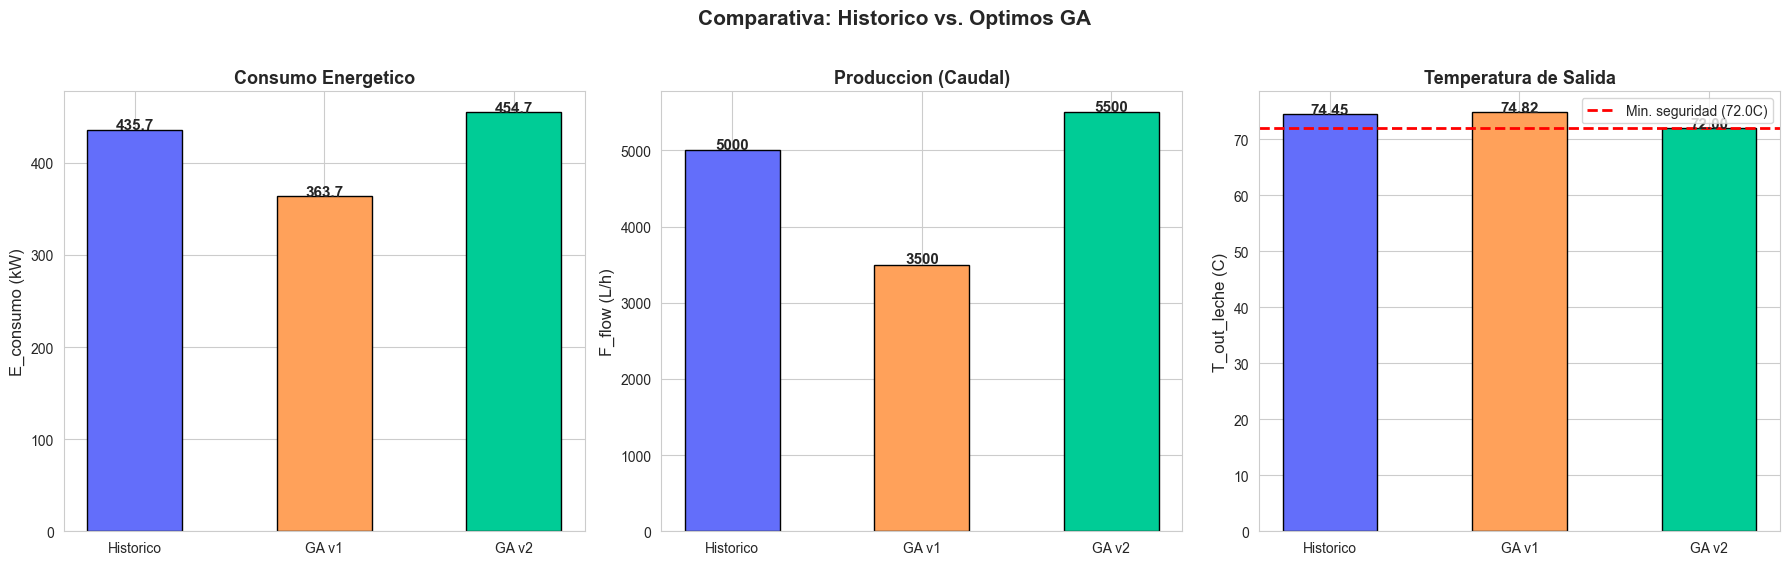

In [ ]:
# ==========================================
# COMPARATIVA HISTORICO vs. OPTIMO v1 vs. OPTIMO v2
# ==========================================

# Valores historicos medios (punto operativo tipico)
hist_F_flow = df_hist['F_flow'].mean()
hist_T_servicio = df_hist['T_servicio'].mean()

# Prediccion del modelo con parametros historicos (escenario base)
E_hist_pred, T_hist_pred = predict_with_model(
    hist_F_flow, hist_T_servicio,
    SCENARIO['T_in_leche'], SCENARIO['t_ciclo'], SCENARIO['Delta_P']
)

# Cargar resultados de GA v1 si existen
ga_v1_report_path = "../../models/metrics/ga_optimization_report.json"
v1_available = False
if os.path.exists(ga_v1_report_path):
    with open(ga_v1_report_path, "r") as f:
        ga_v1_report = json.load(f)
    v1_F_flow = ga_v1_report['selected_solution']['F_flow_opt_Lh']
    v1_T_servicio = ga_v1_report['selected_solution']['T_servicio_opt_C']
    v1_E = ga_v1_report['selected_solution']['E_consumo_opt_kW']
    v1_T_out = ga_v1_report['selected_solution']['T_out_leche_C']
    v1_available = True
    print("Reporte GA v1 cargado para comparacion.")
else:
    print("Reporte GA v1 no encontrado. Comparacion solo Historico vs v2.")

# --- Ahorros v2 vs historico ---
ahorro_kw_v2 = float(E_hist_pred) - best_E
ahorro_pct_v2 = (ahorro_kw_v2 / float(E_hist_pred)) * 100
cambio_flow_v2 = best_F_flow - hist_F_flow
cambio_flow_pct_v2 = (cambio_flow_v2 / hist_F_flow) * 100

# Etiqueta de seguridad (evitar backslash en f-string)
seguridad_label = "SEGURA" if best_T_out >= T_OUT_MIN else "INSEGURA"

print("=" * 85)
print("COMPARATIVA: OPERACION HISTORICA vs. OPTIMOS GA")
print("=" * 85)

if v1_available:
    print(f"{'Parametro':<25} | {'Historico':<15} | {'GA v1':<15} | {'GA v2':<15} | {'v2 vs Hist':<12}")
    print("-" * 85)
    print(f"{'F_flow (L/h)':<25} | {hist_F_flow:<15.2f} | {v1_F_flow:<15.2f} | {best_F_flow:<15.2f} | {cambio_flow_v2:<+12.2f}")
    print(f"{'T_servicio (C)':<25} | {hist_T_servicio:<15.2f} | {v1_T_servicio:<15.2f} | {best_T_servicio:<15.2f} | {best_T_servicio - hist_T_servicio:<+12.2f}")
    print(f"{'E_consumo (kW)':<25} | {float(E_hist_pred):<15.2f} | {v1_E:<15.2f} | {best_E:<15.2f} | {best_E - float(E_hist_pred):<+12.2f}")
    print(f"{'T_out_leche (C)':<25} | {float(T_hist_pred):<15.2f} | {v1_T_out:<15.2f} | {best_T_out:<15.2f} | {best_T_out - float(T_hist_pred):<+12.2f}")
    ce_hist = float(E_hist_pred) / hist_F_flow
    ce_v1 = v1_E / v1_F_flow
    print(f"{'E/F (kW per L/h)':<25} | {ce_hist:<15.5f} | {ce_v1:<15.5f} | {best_consumo_esp:<15.5f} | {best_consumo_esp - ce_hist:<+12.5f}")
    print("=" * 85)
    print(f"\nAHORRO ENERGETICO v2 vs Historico: {ahorro_kw_v2:.2f} kW ({ahorro_pct_v2:+.2f}%)")
    print(f"CAMBIO EN PRODUCCION v2 vs Historico: {cambio_flow_v2:+.2f} L/h ({cambio_flow_pct_v2:+.2f}%)")
    print(f"T_out_leche = {best_T_out:.2f} C [{seguridad_label}]")
    
    # Comparativa v1 vs v2
    print(f"\n--- Comparativa GA v1 vs GA v2 ---")
    print(f"   v1 F_flow: {v1_F_flow:.2f} L/h -> v2 F_flow: {best_F_flow:.2f} L/h ({best_F_flow - v1_F_flow:+.2f})")
    print(f"   v1 E_consumo: {v1_E:.2f} kW -> v2 E_consumo: {best_E:.2f} kW ({best_E - v1_E:+.2f})")
    print(f"   v1 E/F: {ce_v1:.5f} -> v2 E/F: {best_consumo_esp:.5f} ({best_consumo_esp - ce_v1:+.5f})")
    if best_F_flow > v1_F_flow:
        print(f"   v2 produce {best_F_flow - v1_F_flow:.0f} L/h MAS que v1 sin sacrificar seguridad.")
else:
    print(f"{'Parametro':<25} | {'Historico':<15} | {'GA v2':<15} | {'Delta':<12}")
    print("-" * 72)
    print(f"{'F_flow (L/h)':<25} | {hist_F_flow:<15.2f} | {best_F_flow:<15.2f} | {cambio_flow_v2:<+12.2f}")
    print(f"{'T_servicio (C)':<25} | {hist_T_servicio:<15.2f} | {best_T_servicio:<15.2f} | {best_T_servicio - hist_T_servicio:<+12.2f}")
    print(f"{'E_consumo (kW)':<25} | {float(E_hist_pred):<15.2f} | {best_E:<15.2f} | {best_E - float(E_hist_pred):<+12.2f}")
    print(f"{'T_out_leche (C)':<25} | {float(T_hist_pred):<15.2f} | {best_T_out:<15.2f} | {best_T_out - float(T_hist_pred):<+12.2f}")
    print("=" * 72)
    print(f"\nAHORRO ENERGETICO: {ahorro_kw_v2:.2f} kW ({ahorro_pct_v2:+.2f}%)")
    print(f"CAMBIO EN PRODUCCION: {cambio_flow_v2:+.2f} L/h ({cambio_flow_pct_v2:+.2f}%)")
    print(f"T_out_leche = {best_T_out:.2f} C [{seguridad_label}]")

# --- Grafico de barras comparativo ---
if v1_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    labels = ['Historico', 'GA v1', 'GA v2']
    colors_bars = ['#636EFA', '#FFA15A', '#00CC96']
    
    # E_consumo
    vals_E = [float(E_hist_pred), v1_E, best_E]
    bars1 = axes[0].bar(labels, vals_E, color=colors_bars, edgecolor='black', width=0.5)
    axes[0].set_ylabel("E_consumo (kW)", fontsize=12)
    axes[0].set_title("Consumo Energetico", fontsize=13, fontweight='bold')
    for bar, val in zip(bars1, vals_E):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)
    
    # F_flow
    vals_F = [hist_F_flow, v1_F_flow, best_F_flow]
    bars2 = axes[1].bar(labels, vals_F, color=colors_bars, edgecolor='black', width=0.5)
    axes[1].set_ylabel("F_flow (L/h)", fontsize=12)
    axes[1].set_title("Produccion (Caudal)", fontsize=13, fontweight='bold')
    for bar, val in zip(bars2, vals_F):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'{val:.0f}', ha='center', fontweight='bold', fontsize=11)
    
    # T_out_leche
    vals_T = [float(T_hist_pred), v1_T_out, best_T_out]
    bars3 = axes[2].bar(labels, vals_T, color=colors_bars, edgecolor='black', width=0.5)
    axes[2].axhline(y=T_OUT_MIN, color='red', linestyle='--', linewidth=2, label=f'Min. seguridad ({T_OUT_MIN}C)')
    axes[2].set_ylabel("T_out_leche (C)", fontsize=12)
    axes[2].set_title("Temperatura de Salida", fontsize=13, fontweight='bold')
    axes[2].legend(fontsize=10)
    for bar, val in zip(bars3, vals_T):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    labels = ['Historico', 'GA v2']
    colors_bars = ['#636EFA', '#00CC96']
    
    vals_E = [float(E_hist_pred), best_E]
    bars1 = axes[0].bar(labels, vals_E, color=colors_bars, edgecolor='black', width=0.5)
    axes[0].set_ylabel("E_consumo (kW)", fontsize=12)
    axes[0].set_title("Consumo Energetico", fontsize=13, fontweight='bold')
    for bar, val in zip(bars1, vals_E):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)
    
    vals_F = [hist_F_flow, best_F_flow]
    bars2 = axes[1].bar(labels, vals_F, color=colors_bars, edgecolor='black', width=0.5)
    axes[1].set_ylabel("F_flow (L/h)", fontsize=12)
    axes[1].set_title("Produccion (Caudal)", fontsize=13, fontweight='bold')
    for bar, val in zip(bars2, vals_F):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'{val:.0f}', ha='center', fontweight='bold', fontsize=11)
    
    vals_T = [float(T_hist_pred), best_T_out]
    bars3 = axes[2].bar(labels, vals_T, color=colors_bars, edgecolor='black', width=0.5)
    axes[2].axhline(y=T_OUT_MIN, color='red', linestyle='--', linewidth=2, label=f'Min. seguridad ({T_OUT_MIN}C)')
    axes[2].set_ylabel("T_out_leche (C)", fontsize=12)
    axes[2].set_title("Temperatura de Salida", fontsize=13, fontweight='bold')
    axes[2].legend(fontsize=10)
    for bar, val in zip(bars3, vals_T):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle("Comparativa: Historico vs. Optimos GA", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/ga_v2_vs_historico.png", dpi=300, bbox_inches='tight')
plt.show()

## Guardado de Artefactos de Optimización

In [ ]:
# ==========================================
# GUARDADO DE ARTEFACTOS DE OPTIMIZACION v2
# ==========================================

METRICS_DIR = "../../models/metrics"
os.makedirs(METRICS_DIR, exist_ok=True)

# --- Configuracion y resultado del GA v2 ---
ga_report_v2 = {
    "version": "v2",
    "methodology": "NSGA-II (Bi-Objetivo: min E_consumo + max F_flow, restriccion T_out >= 72.3 C)",
    "improvement_over_v1": "F_flow incluido como objetivo a maximizar en lugar de variable libre. T_out como restriccion penalizada.",
    "objectives": ["min E_consumo (kW)", "max F_flow (L/h)"],
    "constraint": "T_out_leche >= 72.3 C (penalizacion proporcional al deficit)",
    "selection_criterion": "min consumo especifico E_consumo / F_flow (kW per L/h)",
    "penalty_factor": PENALTY_FACTOR,
    "scenario_base": SCENARIO,
    "ga_config": GA_CONFIG,
    "bounds": {k: list(v) for k, v in BOUNDS.items()},
    "constraint_T_out_min": T_OUT_MIN,
    "pareto_front": {
        "n_solutions": len(pareto_front),
        "n_feasible": len(feasible),
        "E_consumo_range": [round(min(pareto_E), 2), round(max(pareto_E), 2)],
        "F_flow_range": [round(min(pareto_F), 2), round(max(pareto_F), 2)],
        "T_out_range": [round(min(pareto_T), 2), round(max(pareto_T), 2)]
    },
    "selected_solution": {
        "criterion": "min E_consumo/F_flow with T_out >= 72.3 C",
        "F_flow_opt_Lh": round(float(best_F_flow), 2),
        "T_servicio_opt_C": round(float(best_T_servicio), 2),
        "E_consumo_opt_kW": round(float(best_E), 2),
        "T_out_leche_C": round(float(best_T_out), 2),
        "consumo_especifico_kW_per_Lh": round(float(best_consumo_esp), 5),
        "constraint_satisfied": bool(best_T_out >= T_OUT_MIN)
    },
    "comparison_vs_historical": {
        "E_consumo_historico_kW": round(float(E_hist_pred), 2),
        "F_flow_historico_Lh": round(float(hist_F_flow), 2),
        "ahorro_kW": round(float(ahorro_kw_v2), 2),
        "ahorro_pct": round(float(ahorro_pct_v2), 2),
        "cambio_flow_Lh": round(float(cambio_flow_v2), 2),
        "cambio_flow_pct": round(float(cambio_flow_pct_v2), 2)
    }
}

with open(f"{METRICS_DIR}/ga_v2_optimization_report.json", "w") as f:
    json.dump(ga_report_v2, f, indent=4)

# Guardar tabla Pareto como CSV
df_pareto.to_csv(f"{PREDICTIONS_DIR}/ga_v2_pareto_front.csv", index=False)

print("Artefactos de optimizacion v2 guardados:")
print(f"   {METRICS_DIR}/ga_v2_optimization_report.json")
print(f"   {PREDICTIONS_DIR}/ga_v2_optimization_results.csv")
print(f"   {PREDICTIONS_DIR}/ga_v2_pareto_front.csv")
print(f"   {IMAGES_DIR}/ga_v2_pareto_convergence.png")
print(f"   {IMAGES_DIR}/ga_v2_multi_scenario_heatmaps.png")
print(f"   {IMAGES_DIR}/ga_v2_vs_historico.png")

Artefactos de optimizacion v2 guardados:
   ../../models/metrics/ga_v2_optimization_report.json
   ../../data/predictions/ga_v2_optimization_results.csv
   ../../data/predictions/ga_v2_pareto_front.csv
   ../../data/images/ga_v2_pareto_convergence.png
   ../../data/images/ga_v2_multi_scenario_heatmaps.png
   ../../data/images/ga_v2_vs_historico.png


## Dashboard Comparativo: Histórico vs. Óptimo GA

Visualización completa de todas las variables operativas relevantes comparando el funcionamiento histórico de la planta con la operación optimizada por el GA:

| Régimen | Descripción |
|---------|-------------|
| **Histórico** | Media real de operación de la planta (sin optimizar) |
| **Óptimo GA** | Optimización min E_consumo + max F_flow con T_out ≥ 72.3 °C |

Se presentan:
1. **Barras agrupadas** de todas las variables de decisión y respuesta
2. **Gráfico radar** normalizado para comparar ambos perfiles operativos
3. **Tabla resumen** con deltas absolutos y porcentuales

TABLA RESUMEN COMPARATIVA: HISTORICO vs. GA v1 vs. GA v2
        Metrica  Historico     GA_v1     GA_v2  v1_vs_Hist  v1_vs_Hist_%  v2_vs_Hist  v2_vs_Hist_%  v2_vs_v1  v2_vs_v1_%
   F_flow (L/h)  4999.7979 3500.0000 5500.0000  -1499.7979      -29.9972    500.2021       10.0044 2000.0000     57.1429
 T_servicio (C)    83.4715   80.0000   80.9193     -3.4715       -4.1589     -2.5522       -3.0576    0.9193      1.1491
 E_consumo (kW)   435.7113  363.7400  454.7457    -71.9713      -16.5181     19.0344        4.3686   91.0057     25.0194
T_out_leche (C)    74.4483   74.8200   72.0001      0.3717        0.4993     -2.4482       -3.2885   -2.8199     -3.7690
   E/F kW/(L/h)     0.0871    0.1039    0.0827      0.0168       19.2550     -0.0045       -5.1233   -0.0212    -20.4422


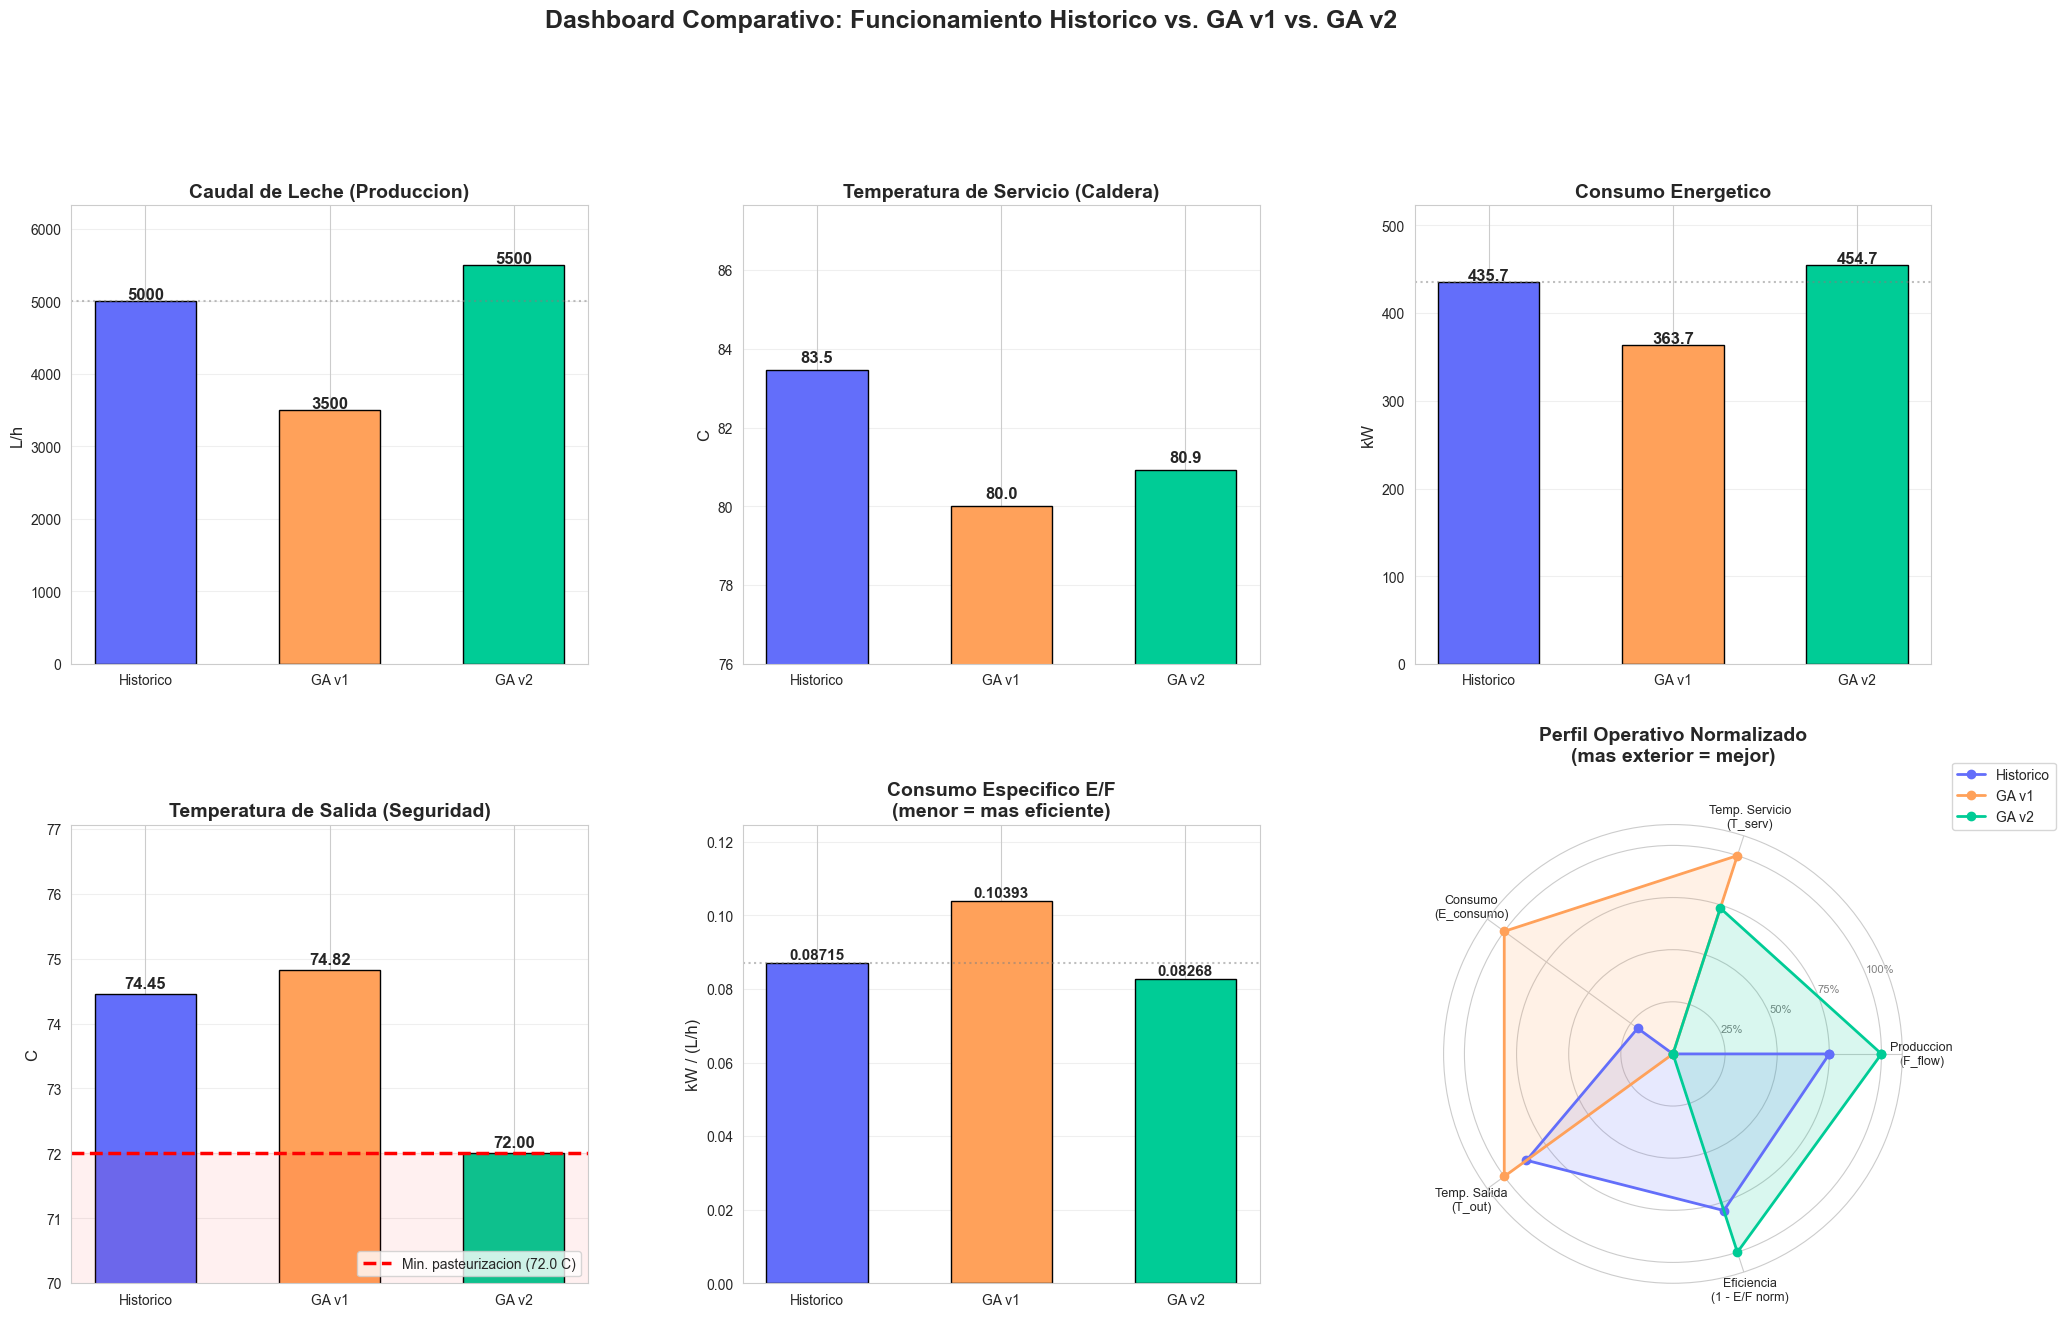


RESUMEN DE CAMBIOS POR VARIABLE
Variable               |    Historico |        GA v1 |        GA v2 |   v1 vs Hist |   v2 vs Hist |     v2 vs v1
----------------------------------------------------------------------------------------------------------------------------------
F_flow (L/h)           |         5000 |         3500 |         5500 |        -1500 |         +500 |        +2000
T_servicio (C)         |         83.5 |         80.0 |         80.9 |         -3.5 |         -2.6 |         +0.9
E_consumo (kW)         |       435.71 |       363.74 |       454.75 |       -71.97 |       +19.03 |       +91.01
T_out_leche (C)        |        74.45 |        74.82 |        72.00 |        +0.37 |        -2.45 |        -2.82
E/F kW/(L/h)           |      0.08715 |      0.10393 |      0.08268 |     +0.01678 |     -0.00446 |     -0.02124

INTERPRETACION:
  - GA v1 ahorra 72.0 kW (16.5%) pero pierde 1500 L/h de produccion (30.0%)
  - GA v2 consume +19.0 kW (+4.4%) pero con +500 L/h de produccio

In [ ]:
# ==========================================
# DASHBOARD COMPARATIVO COMPLETO
#     Historico vs. GA v1 vs. GA v2
# ==========================================
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

# --- Construir DataFrame de comparacion ---
# Historico
hist_E = float(E_hist_pred)
hist_T = float(T_hist_pred)
hist_Ts = float(hist_T_servicio)
hist_Ff = float(hist_F_flow)
hist_CE = hist_E / hist_Ff

# GA v1 (cargado del JSON)
v1_CE = v1_E / v1_F_flow

# GA v2 (del escenario base de este cuaderno)
v2_E = best_E
v2_T = best_T_out
v2_Ts = best_T_servicio
v2_Ff = best_F_flow
v2_CE = best_consumo_esp

# DataFrame con todas las metricas
comparativa = pd.DataFrame({
    'Metrica': [
        'F_flow (L/h)',
        'T_servicio (C)',
        'E_consumo (kW)',
        'T_out_leche (C)',
        'E/F kW/(L/h)',
    ],
    'Historico': [hist_Ff, hist_Ts, hist_E, hist_T, hist_CE],
    'GA_v1':     [v1_F_flow, v1_T_servicio, v1_E, v1_T_out, v1_CE],
    'GA_v2':     [v2_Ff, v2_Ts, v2_E, v2_T, v2_CE],
})

# Deltas v1 vs historico
comparativa['v1_vs_Hist'] = comparativa['GA_v1'] - comparativa['Historico']
comparativa['v1_vs_Hist_%'] = (comparativa['v1_vs_Hist'] / comparativa['Historico']) * 100

# Deltas v2 vs historico
comparativa['v2_vs_Hist'] = comparativa['GA_v2'] - comparativa['Historico']
comparativa['v2_vs_Hist_%'] = (comparativa['v2_vs_Hist'] / comparativa['Historico']) * 100

# Deltas v2 vs v1
comparativa['v2_vs_v1'] = comparativa['GA_v2'] - comparativa['GA_v1']
comparativa['v2_vs_v1_%'] = (comparativa['v2_vs_v1'] / comparativa['GA_v1']) * 100

print("=" * 120)
print("TABLA RESUMEN COMPARATIVA: HISTORICO vs. GA v1 vs. GA v2")
print("=" * 120)
print(comparativa.to_string(index=False, float_format='%.4f'))
print("=" * 120)

# =============================================
# FIGURA PRINCIPAL: 6 paneles (2x3)
# =============================================
fig = plt.figure(figsize=(24, 14))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3)

regimes = ['Historico', 'GA v1', 'GA v2']
colors = ['#636EFA', '#FFA15A', '#00CC96']

# --- Panel 1: F_flow (Produccion) ---
ax1 = fig.add_subplot(gs[0, 0])
vals = [hist_Ff, v1_F_flow, v2_Ff]
bars = ax1.bar(regimes, vals, color=colors, edgecolor='black', width=0.55)
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 30,
             f'{v:.0f}', ha='center', fontweight='bold', fontsize=12)
ax1.set_ylabel("L/h", fontsize=12)
ax1.set_title("Caudal de Leche (Produccion)", fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(vals) * 1.15)
ax1.axhline(y=hist_Ff, color='gray', linestyle=':', alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

# --- Panel 2: T_servicio (Temperatura caldera) ---
ax2 = fig.add_subplot(gs[0, 1])
vals = [hist_Ts, v1_T_servicio, v2_Ts]
bars = ax2.bar(regimes, vals, color=colors, edgecolor='black', width=0.55)
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
             f'{v:.1f}', ha='center', fontweight='bold', fontsize=12)
ax2.set_ylabel("C", fontsize=12)
ax2.set_title("Temperatura de Servicio (Caldera)", fontsize=14, fontweight='bold')
ax2.set_ylim(min(vals) * 0.95, max(vals) * 1.05)
ax2.grid(axis='y', alpha=0.3)

# --- Panel 3: E_consumo (Consumo energetico) ---
ax3 = fig.add_subplot(gs[0, 2])
vals = [hist_E, v1_E, v2_E]
bars = ax3.bar(regimes, vals, color=colors, edgecolor='black', width=0.55)
for b, v in zip(bars, vals):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
             f'{v:.1f}', ha='center', fontweight='bold', fontsize=12)
ax3.set_ylabel("kW", fontsize=12)
ax3.set_title("Consumo Energetico", fontsize=14, fontweight='bold')
ax3.set_ylim(0, max(vals) * 1.15)
ax3.axhline(y=hist_E, color='gray', linestyle=':', alpha=0.5)
ax3.grid(axis='y', alpha=0.3)

# --- Panel 4: T_out_leche (Temperatura de salida) ---
ax4 = fig.add_subplot(gs[1, 0])
vals = [hist_T, v1_T_out, v2_T]
bars = ax4.bar(regimes, vals, color=colors, edgecolor='black', width=0.55)
for b, v in zip(bars, vals):
    ax4.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
             f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
ax4.axhline(y=T_OUT_MIN, color='red', linestyle='--', linewidth=2.5,
            label=f'Min. pasteurizacion ({T_OUT_MIN} C)')
ax4.axhspan(0, T_OUT_MIN, alpha=0.06, color='red')
ax4.set_ylabel("C", fontsize=12)
ax4.set_title("Temperatura de Salida (Seguridad)", fontsize=14, fontweight='bold')
ax4.set_ylim(T_OUT_MIN - 2, max(vals) * 1.03)
ax4.legend(fontsize=10, loc='lower right')
ax4.grid(axis='y', alpha=0.3)

# --- Panel 5: Consumo Especifico E/F ---
ax5 = fig.add_subplot(gs[1, 1])
vals = [hist_CE, v1_CE, v2_CE]
bars = ax5.bar(regimes, vals, color=colors, edgecolor='black', width=0.55)
for b, v in zip(bars, vals):
    ax5.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
             f'{v:.5f}', ha='center', fontweight='bold', fontsize=11)
ax5.set_ylabel("kW / (L/h)", fontsize=12)
ax5.set_title("Consumo Especifico E/F\n(menor = mas eficiente)", fontsize=14, fontweight='bold')
ax5.set_ylim(0, max(vals) * 1.2)
ax5.axhline(y=hist_CE, color='gray', linestyle=':', alpha=0.5)
ax5.grid(axis='y', alpha=0.3)

# --- Panel 6: Grafico Radar (Perfil Normalizado) ---
ax6 = fig.add_subplot(gs[1, 2], polar=True)

# Variables para el radar (normalizadas 0-1 respecto al rango de los 3 valores)
radar_labels = ['Produccion\n(F_flow)', 'Temp. Servicio\n(T_serv)', 
                'Consumo\n(E_consumo)', 'Temp. Salida\n(T_out)', 
                'Eficiencia\n(1 - E/F norm)']

# Valores raw
raw_data = {
    'Historico': [hist_Ff, hist_Ts, hist_E, hist_T, hist_CE],
    'GA v1':     [v1_F_flow, v1_T_servicio, v1_E, v1_T_out, v1_CE],
    'GA v2':     [v2_Ff, v2_Ts, v2_E, v2_T, v2_CE],
}

# Normalizar cada variable 0-1 (mas alto = mejor para produccion/T_out, 
# mas bajo = mejor para E_consumo/T_servicio/CE)
# Invertimos E_consumo, T_servicio y CE para que "mas grande en el radar = mejor"
normalized = {}
for regime in regimes:
    norm_vals = []
    for i, metric_vals in enumerate(zip(
        [hist_Ff, v1_F_flow, v2_Ff],
        [hist_Ts, v1_T_servicio, v2_Ts],
        [hist_E, v1_E, v2_E],
        [hist_T, v1_T_out, v2_T],
        [hist_CE, v1_CE, v2_CE],
    )):
        pass
    
    vals_raw = raw_data[regime]
    all_vals = list(zip(*raw_data.values()))
    
    norm = []
    for j, val in enumerate(vals_raw):
        min_v = min(all_vals[j])
        max_v = max(all_vals[j])
        rng = max_v - min_v if max_v != min_v else 1.0
        if j in [1, 2, 4]:
            norm.append(1.0 - (val - min_v) / rng)
        else:
            norm.append((val - min_v) / rng)
    normalized[regime] = norm

# Dibujar radar
n_vars = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

for regime, color in zip(regimes, colors):
    values = normalized[regime] + normalized[regime][:1]
    ax6.fill(angles, values, alpha=0.15, color=color)
    ax6.plot(angles, values, 'o-', linewidth=2, markersize=6, color=color, label=regime)

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(radar_labels, fontsize=9)
ax6.set_ylim(0, 1.1)
ax6.set_yticks([0.25, 0.5, 0.75, 1.0])
ax6.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
ax6.set_title("Perfil Operativo Normalizado\n(mas exterior = mejor)", 
              fontsize=14, fontweight='bold', y=1.12)
ax6.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.suptitle("Dashboard Comparativo: Funcionamiento Historico vs. GA v1 vs. GA v2",
             fontsize=18, fontweight='bold', y=1.02)
plt.savefig(f"{IMAGES_DIR}/ga_dashboard_comparativo.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# TABLA FINAL CON DELTAS
# =============================================
print("\n" + "=" * 130)
print("RESUMEN DE CAMBIOS POR VARIABLE")
print("=" * 130)
header = f"{'Variable':<22} | {'Historico':>12} | {'GA v1':>12} | {'GA v2':>12} | {'v1 vs Hist':>12} | {'v2 vs Hist':>12} | {'v2 vs v1':>12}"
print(header)
print("-" * 130)

metrics_info = [
    ('F_flow (L/h)',      hist_Ff, v1_F_flow,       v2_Ff, '.0f', 'Produccion'),
    ('T_servicio (C)',    hist_Ts, v1_T_servicio,    v2_Ts, '.1f', 'Caldera'),
    ('E_consumo (kW)',    hist_E,  v1_E,             v2_E,  '.2f', 'Consumo'),
    ('T_out_leche (C)',   hist_T,  v1_T_out,         v2_T,  '.2f', 'Seguridad'),
    ('E/F kW/(L/h)',      hist_CE, v1_CE,            v2_CE, '.5f', 'Eficiencia'),
]

for name, h, v1, v2, fmt, cat in metrics_info:
    d_v1 = v1 - h
    d_v2 = v2 - h
    d_v2v1 = v2 - v1
    row = f"{name:<22} | {h:>12{fmt}} | {v1:>12{fmt}} | {v2:>12{fmt}} | {d_v1:>+12{fmt}} | {d_v2:>+12{fmt}} | {d_v2v1:>+12{fmt}}"
    print(row)

print("=" * 130)

# Interpretacion automatica
print("\nINTERPRETACION:")
print(f"  - GA v1 ahorra {hist_E - v1_E:.1f} kW ({(hist_E - v1_E)/hist_E*100:.1f}%) pero pierde {hist_Ff - v1_F_flow:.0f} L/h de produccion ({(hist_Ff - v1_F_flow)/hist_Ff*100:.1f}%)")
print(f"  - GA v2 consume {v2_E - hist_E:+.1f} kW ({(v2_E - hist_E)/hist_E*100:+.1f}%) pero con {v2_Ff - hist_Ff:+.0f} L/h de produccion ({(v2_Ff - hist_Ff)/hist_Ff*100:+.1f}%)")
print(f"  - Consumo especifico E/F: Historico={hist_CE:.5f} | v1={v1_CE:.5f} | v2={v2_CE:.5f}")

# Destacar ganador en eficiencia
ef_values = {'Historico': hist_CE, 'GA v1': v1_CE, 'GA v2': v2_CE}
ganador = min(ef_values, key=ef_values.get)
print(f"  - GANADOR en eficiencia (menor E/F): {ganador} con {ef_values[ganador]:.5f} kW/(L/h)")

# Seguridad
all_safe = all(t >= T_OUT_MIN for t in [hist_T, v1_T_out, v2_T])
print(f"  - Seguridad alimentaria (T_out >= {T_OUT_MIN} C): {'TODOS cumplen' if all_safe else 'HAY INCUMPLIMIENTOS'}")
print(f"\nGrafico guardado en: {IMAGES_DIR}/ga_dashboard_comparativo.png")